# Subtask 4 — Open Source Model Heatmap (Prompt 1–10)
Visualizes micro-F1 / overall score for the 10 open-source models across prompt IDs 1–10.

In [16]:
import json
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path

RESULTS_DIR = Path('../results/dev')

In [17]:
# Load all result files and parse model name, prompt_id, and overall_score
def load_scores(results_dir):
    data = []
    for file_path in results_dir.glob('*.json'):
        try:
            with open(file_path, 'r') as f:
                metrics = json.load(f)
            filename = file_path.stem
            if '_prompt_' in filename:
                model_name, prompt_part = filename.rsplit('_prompt_', 1)
                prompt_id = prompt_part
            else:
                model_name = filename
                prompt_id = 'unknown'
            data.append({
                'model': model_name,
                'prompt_id': prompt_id,
                'overall_score': metrics.get('overall_score', None),
            })
        except Exception as e:
            print(f'Error reading {file_path}: {e}')
    return pd.DataFrame(data)

df = load_scores(RESULTS_DIR)

In [18]:
# Filter to prompt IDs 1–10 only (excludes prompt_0, _11, _12, prefixed, twostep, etc.)
df['prompt_id'] = pd.to_numeric(df['prompt_id'], errors='coerce')
df = df.dropna(subset=['prompt_id'])
df['prompt_id'] = df['prompt_id'].astype(int)
df = df[df['prompt_id'].between(1, 10)]

print("Models found:", sorted(df['model'].unique()))
print("Prompt IDs:", sorted(df['prompt_id'].unique()))

Models found: ['BioMistral-BioMistral-7B', 'Echelon-AI-Med-Qwen2-7B', 'Qwen-Qwen3-32b', 'Qwen-Qwen3-8B', 'anthropic-claude-haiku-4-5', 'anthropic-claude-opus-4-5', 'anthropic-claude-opus-4-6', 'anthropic-claude-sonnet-4', 'anthropic-claude-sonnet-4-5', 'anthropic-claude-sonnet-4-6', 'deepseek-deepseek-chat-v3-0324', 'deepseek-deepseek-v3-2', 'google-gemini-2-0-flash-001', 'google-gemini-2-5-flash', 'google-gemini-2-5-flash-lite', 'google-gemini-2-5-flash-lite-preview-09-2025', 'google-gemini-2-5-pro', 'google-gemini-3-1-pro-preview', 'google-gemini-3-flash-preview', 'google-gemini-3-pro-preview', 'google-gemma-3-27b-it', 'google-medgemma-1-5-4b-it', 'google-medgemma-27b-text-it', 'google-medgemma-4b-it', 'khazarai-Bio-8B-it', 'meta-llama-Llama-3-1-8B-Instruct', 'meta-llama-llama-3-3-70b-instruct', 'meta-llama-llama-4-scout', 'minimax-minimax-m2-1', 'minimax-minimax-m2-5', 'moonshotai-kimi-k2-5', 'moonshotai-kimi-k2-thinking', 'nvidia-nemotron-3-nano-30b-a3b:free', 'openai-gpt-4-1', 'op

In [19]:
df

,model,prompt_id,overall_score
2,Echelon-AI-Med-Qwen2-7B,8,48.000000
4,google-gemini-2-5-flash,2,86.988848
7,google-medgemma-4b-it,2,26.168224
8,anthropic-claude-opus-4-6,7,85.416667
9,Echelon-AI-Med-Qwen2-7B,10,9.489051
...,...,...,...
265,Qwen-Qwen3-32b,5,0.000000
267,Qwen-Qwen3-8B,10,0.000000
268,openai-gpt-5-mini,7,80.620155
269,x-ai-grok-4-fast,6,85.171103


In [4]:
# --- Define model groups ---
closed_source_models = [
    'google-gemini-2-5-flash',
    'openai-gpt-4-1',
    'x-ai-grok-4-fast',
    'openai-gpt-5',
    'google-gemini-2-0-flash-001',
    'anthropic-claude-opus-4-5',
    'anthropic-claude-opus-4-6',
    'anthropic-claude-sonnet-4-5',
    'google-gemini-3-flash-preview',
    'anthropic-claude-sonnet-4',
    'x-ai-grok-4-1-fast',
    # 'nvidia-nemotron-3-nano-30b-a3b:free',
    # 'deepseek-deepseek-v3-2',
    'qwen-qwen3-max-thinking',
]

open_source_models = [
    'google-medgemma-27b-text-it',
    'google-medgemma-4b-it',
    'google-gemma-3-27b-it',
    'google-medgemma-1-5-4b-it',
    'khazarai-Bio-8B-it',
    'Qwen-Qwen3-8B',
    'Qwen-Qwen3-32b',
    'BioMistral-BioMistral-7B',
    'Echelon-AI-Med-Qwen2-7B',
    'meta-llama-Llama-3-1-8B-Instruct',
]

all_models = closed_source_models + open_source_models

# Filter df to only the target models
df_filtered = df[df['model'].isin(all_models)]

# Build pivot table: rows = model, columns = prompt_id, values = overall_score
pivot_df = df_filtered.pivot_table(index='model', columns='prompt_id', values='overall_score')

# Add Average column and row
pivot_df['Average'] = pivot_df.mean(axis=1)
pivot_df.loc['Average'] = pivot_df.mean(axis=0)

# Sort each group by average score (descending)
def get_avg(model):
    try:
        return pivot_df.loc[model, 'Average']
    except KeyError:
        return -float('inf')

closed_sorted = sorted([m for m in closed_source_models if m in pivot_df.index], key=get_avg, reverse=True)
open_sorted = sorted([m for m in open_source_models if m in pivot_df.index], key=get_avg, reverse=True)

# Closed first, then open, then Average row
pivot_df = pivot_df.reindex(closed_sorted + open_sorted + ['Average'])

pivot_df

prompt_id,1,2,3,4,5,6,7,8,9,10,Average
model,,,,,,,,,,,
openai-gpt-4-1,NaN,NaN,NaN,NaN,88.148148,88.970588,87.108014,NaN,NaN,NaN,88.075583
anthropic-claude-opus-4-5,NaN,NaN,NaN,88.321168,89.377289,85.925926,87.234043,NaN,NaN,NaN,87.714606
google-gemini-2-5-flash,82.962963,86.988848,NaN,89.130435,89.781022,89.552239,89.122807,89.436620,88.652482,83.274021,87.655715
anthropic-claude-opus-4-6,NaN,NaN,NaN,87.681159,88.727273,84.782609,85.416667,NaN,NaN,NaN,86.651927
anthropic-claude-sonnet-4-5,NaN,NaN,NaN,86.245353,86.988848,86.466165,85.714286,NaN,NaN,NaN,86.353663
google-gemini-2-0-flash-001,NaN,NaN,NaN,NaN,89.051095,86.567164,86.021505,85.507246,87.732342,82.264151,86.190584
x-ai-grok-4-fast,NaN,NaN,NaN,87.313433,87.407407,85.171103,83.582090,NaN,NaN,NaN,85.868508
anthropic-claude-sonnet-4,NaN,NaN,NaN,86.692015,86.153846,84.496124,85.925926,NaN,NaN,NaN,85.816978
google-gemini-3-flash-preview,NaN,NaN,NaN,87.234043,86.805556,87.285223,85.714286,NaN,NaN,80.677966,85.543415


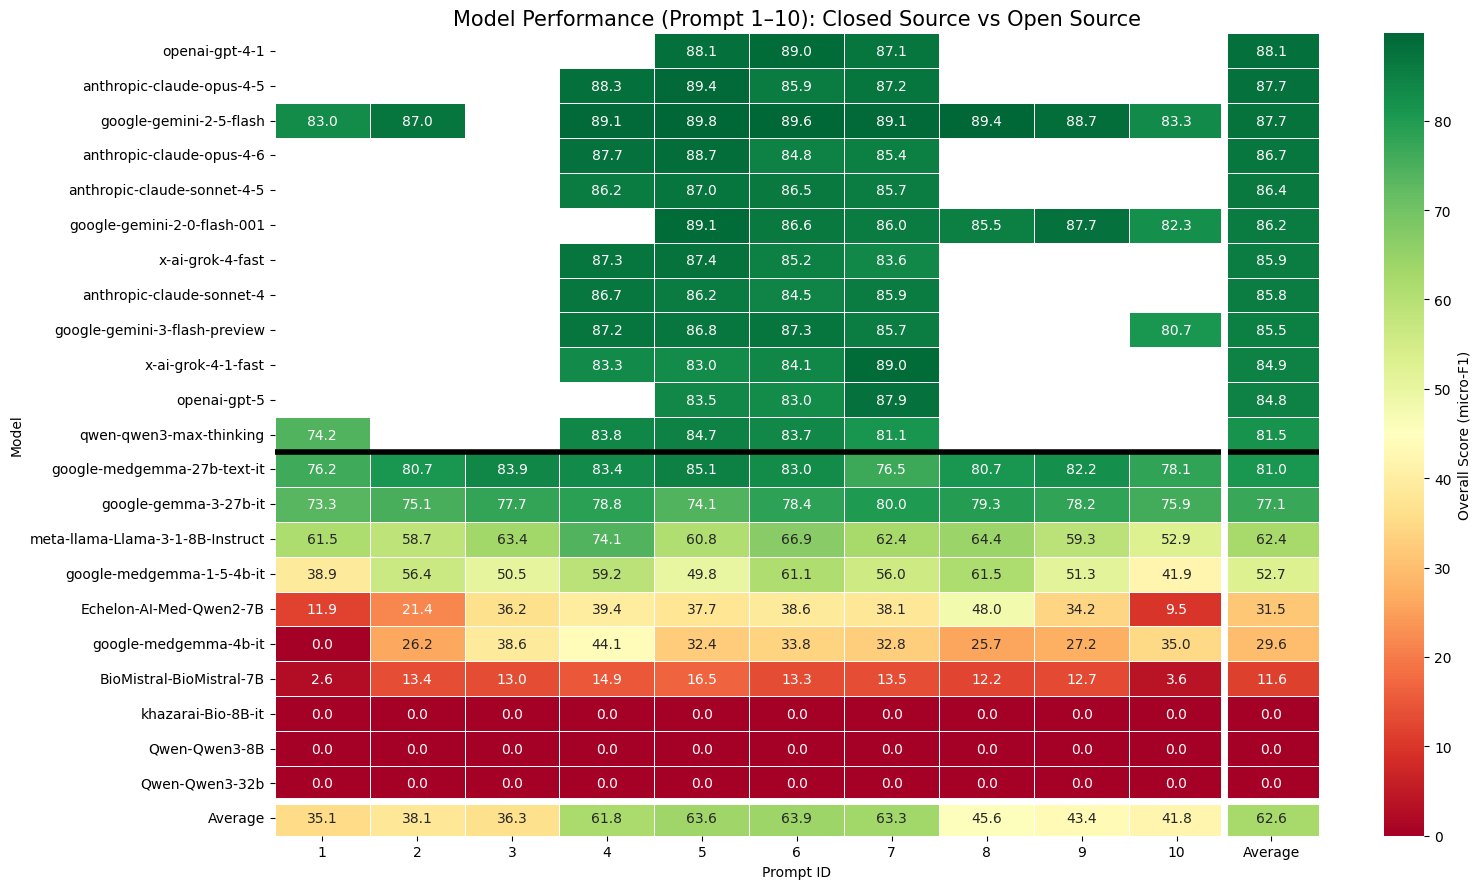

In [9]:
# Plot heatmap
n_closed = len(closed_sorted)
plt.figure(figsize=(16, max(9, (len(closed_sorted) + len(open_sorted)) * 0.25)))
ax = sns.heatmap(
    pivot_df,
    annot=True,
    fmt='.1f',
    cmap='RdYlGn',
    linewidths=0.5,
    cbar_kws={'label': 'Overall Score (micro-F1)'},
)

# Black thick line separating closed source from open source models
ax.axhline(y=n_closed, color='black', linewidth=4)

# White line separating the Average column from prompt columns
ax.axvline(x=pivot_df.shape[1] - 1, color='white', linewidth=5)

# White line separating the Average row from model rows
ax.axhline(y=pivot_df.shape[0] - 1, color='white', linewidth=5)

plt.title('Model Performance (Prompt 1–10): Closed Source vs Open Source', fontsize=15)
plt.ylabel('Model')
plt.xlabel('Prompt ID')
plt.tight_layout()
plt.savefig('subtask4_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()


Models found: ['BioMistral-BioMistral-7B', 'Echelon-AI-Med-Qwen2-7B', 'Qwen-Qwen3-32b', 'Qwen-Qwen3-8B', 'anthropic-claude-haiku-4-5', 'anthropic-claude-opus-4-5', 'anthropic-claude-opus-4-6', 'anthropic-claude-sonnet-4', 'anthropic-claude-sonnet-4-5', 'anthropic-claude-sonnet-4-6', 'deepseek-deepseek-chat-v3-0324', 'deepseek-deepseek-v3-2', 'google-gemini-2-0-flash-001', 'google-gemini-2-5-flash', 'google-gemini-2-5-flash-lite', 'google-gemini-2-5-flash-lite-preview-09-2025', 'google-gemini-2-5-pro', 'google-gemini-3-1-pro-preview', 'google-gemini-3-flash-preview', 'google-gemini-3-pro-preview', 'google-gemma-3-27b-it', 'google-medgemma-1-5-4b-it', 'google-medgemma-27b-text-it', 'google-medgemma-4b-it', 'khazarai-Bio-8B-it', 'meta-llama-Llama-3-1-8B-Instruct', 'meta-llama-llama-3-3-70b-instruct', 'meta-llama-llama-4-scout', 'minimax-minimax-m2-1', 'minimax-minimax-m2-5', 'moonshotai-kimi-k2-5', 'moonshotai-kimi-k2-thinking', 'nvidia-nemotron-3-nano-30b-a3b:free', 'openai-gpt-4-1', 'op

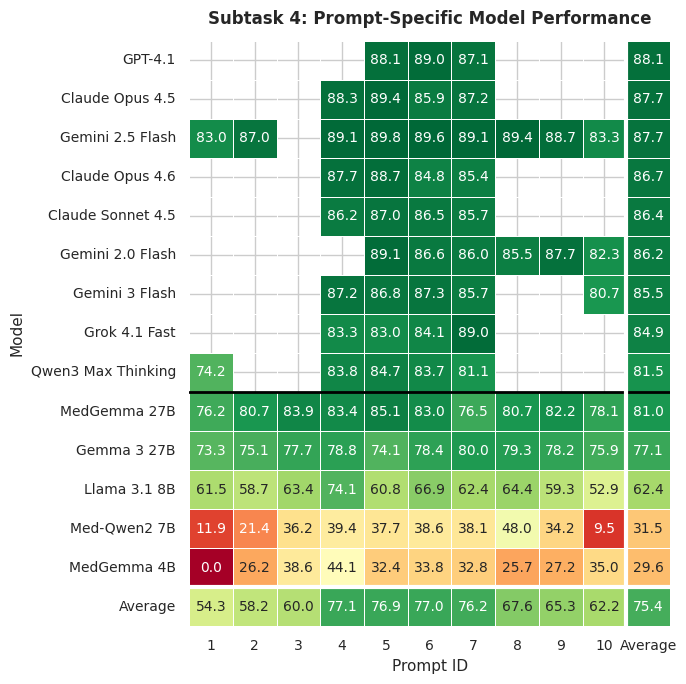

In [33]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams['figure.figsize'] = (12, 6)

# ── Dev set heatmap (Closed Source vs Open Source) ───────────────────────────
DEV_RESULTS_DIR = "../results/dev"

df_dev = load_scores(RESULTS_DIR)


# Filter to prompt IDs 1–10 only (excludes prompt_0, _11, _12, prefixed, twostep, etc.)
df_dev['prompt_id'] = pd.to_numeric(df_dev['prompt_id'], errors='coerce')
df_dev = df_dev.dropna(subset=['prompt_id'])
df_dev['prompt_id'] = df_dev['prompt_id'].astype(int)
df_dev = df_dev[df_dev['prompt_id'].between(1, 10)]

print("Models found:", sorted(df['model'].unique()))
print("Prompt IDs:", sorted(df['prompt_id'].unique()))

# df_dev['prompt_id'] = pd.to_numeric(df_dev['prompt_id'], errors='coerce')
# df_dev = df_dev.dropna(subset=['prompt_id'])
# df_dev['prompt_id'] = df_dev['prompt_id'].astype(int)
# print(f"Loaded {len(df_dev)} dev result files.")

closed_source_models = [
    'anthropic-claude-sonnet-4-5',   
    'anthropic-claude-opus-4-5',   
    'anthropic-claude-opus-4-6',   

    'google-gemini-3-flash-preview', 
    'x-ai-grok-4-1-fast',            
    # 'google-gemini-3-pro-preview',       
    'qwen-qwen3-max',  
    # 'deepseek-deepseek-v3-2',
    'openai-gpt-4-1',
'google-gemini-2-0-flash-001',
    'qwen-qwen3-max-thinking',  
    'google-gemini-2-5-flash'     
]

open_source_models = [
    'meta-llama-Llama-3-1-8B-Instruct', 
    'Qwen-Qwen3-32B',                   
    'google-medgemma-27b-text-it',      
    'google-medgemma-4b-it',            
    'Echelon-AI-Med-Qwen2-7B',          
    'google-gemma-3-27b-it',

]

# ── Define Clean Aliases for the Plot ────────────────────────────────────────
model_aliases = {
    'anthropic-claude-sonnet-4-5': 'Claude Sonnet 4.5',
    'anthropic-claude-opus-4-5': 'Claude Opus 4.5',
    'anthropic-claude-opus-4-6': 'Claude Opus 4.6',
'google-gemini-2-0-flash-001': 'Gemini 2.0 Flash',
    'google-gemini-3-flash-preview': 'Gemini 3 Flash',
    'x-ai-grok-4-1-fast': 'Grok 4.1 Fast',
    'google-gemini-2-5-flash': 'Gemini 2.5 Flash',
    'qwen-qwen3-max-thinking': 'Qwen3 Max Thinking', # Fixed key to match your list above
    'qwen-qwen3-max': 'Qwen3 Max', # Fixed key to match your list above
    'deepseek-deepseek-v3-2':'DeepSeek V3.2',
    'openai-gpt-4-1': 'GPT-4.1',

    'google-gemini-3-pro-preview': 'Gemini 3 Pro',      
    
    'meta-llama-Llama-3-1-8B-Instruct': 'Llama 3.1 8B',
    'Qwen-Qwen3-32B': 'Qwen3 32B',
    'google-medgemma-27b-text-it': 'MedGemma 27B',
    'google-medgemma-4b-it': 'MedGemma 4B',
    'Echelon-AI-Med-Qwen2-7B': 'Med-Qwen2 7B',
    'google-gemma-3-27b-it': 'Gemma 3 27B',

}
# ─────────────────────────────────────────────────────────────────────────────

all_models = closed_source_models + open_source_models

# Build pivot (keep only models present in both the list and the data)
df_dev_filtered = df_dev[df_dev['model'].isin(all_models)]
pivot_dev = df_dev_filtered.pivot_table(index='model', columns='prompt_id', values='overall_score')

# Calculate Averages (Changed to 'Avg')
pivot_dev['Average'] = pivot_dev.mean(axis=1)
pivot_dev.loc['Average'] = pivot_dev.mean(axis=0)

def get_avg_dev(model):
    try:
        return pivot_dev.loc[model, 'Average']
    except KeyError:
        return -float('inf')

# Sort
closed_sorted_dev = sorted([m for m in closed_source_models if m in pivot_dev.index], key=get_avg_dev, reverse=True)
open_sorted_dev   = sorted([m for m in open_source_models   if m in pivot_dev.index], key=get_avg_dev, reverse=True)

# Reindex using 'Avg' instead of 'Average'
pivot_dev = pivot_dev.reindex(closed_sorted_dev + open_sorted_dev + ['Average'])

# Apply the clean aliases to the DataFrame index
pivot_dev.rename(index=model_aliases, inplace=True)

print(f"Closed source: {len(closed_sorted_dev)} models")
print(f"Open source:   {len(open_sorted_dev)} models")

# ── Plotting (Optimized for Legibility in Double-Column) ─────────────────────
n_closed_dev = len(closed_sorted_dev)

# Slightly taller figure to accommodate larger text without overlapping
plt.figure(figsize=(7, 7)) 

# Plot heatmap (colorbar disabled)
ax = sns.heatmap(
    pivot_dev,
    annot=True,
    fmt='.1f',
    cmap='RdYlGn',
    linewidths=0.5,
    annot_kws={"size": 10}, 
    cbar=False # Removes the colorbar from the right
)

# Scale down the separator lines for the smaller figure size
ax.axhline(y=n_closed_dev, color='black', linewidth=2)
ax.axvline(x=pivot_dev.shape[1] - 1, color='white', linewidth=3)
ax.axhline(y=pivot_dev.shape[0] - 1, color='white', linewidth=3)

# Adjust titles and labels with larger, paper-appropriate font sizes (Added "Overall Score")
plt.title('Subtask 4: Prompt-Specific Model Performance', fontsize=12, fontweight='bold', pad=12)
plt.ylabel('Model', fontsize=11)
plt.xlabel('Prompt ID', fontsize=11)

# Clean up ticks and increase their size
plt.xticks(fontsize=10, rotation=0) 
plt.yticks(fontsize=10)

plt.tight_layout()

# Save as PDF at 300 DPI for crisp print quality
plt.savefig('subtask4_heatmap_revised.pdf', dpi=300, bbox_inches='tight')

In [23]:
pivot_dev

prompt_id,0,1,10,11,12,13,14,15,16,17,...,3_prefixed,4,4_prefixed,4_twostep,5,6,7,8,9,Average
model,,,,,,,,,,,,,,,,,,,,,
Claude Sonnet 4.5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,86.245353,NaN,NaN,86.988848,86.466165,85.714286,NaN,NaN,86.353663
DeepSeek V3.2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,83.969466,NaN,NaN,NaN,NaN,83.969466
Gemini 2.5 Flash,25.274725,82.962963,83.274021,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,81.138790,89.130435,81.660900,NaN,89.781022,89.552239,89.122807,89.436620,88.652482,83.618223
Qwen3 Max Thinking,NaN,74.204947,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,83.846154,NaN,NaN,84.732824,83.650190,81.081081,NaN,NaN,81.503039
Gemini 3 Pro,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,68.103448,NaN,NaN,NaN,NaN,68.103448
MedGemma 27B,NaN,76.223776,78.066914,81.818182,81.954887,81.560284,81.203008,79.847909,79.442509,76.975945,...,77.966102,83.394834,79.432624,77.419355,85.090909,83.018868,76.491228,80.714286,82.181818,80.496780
Llama 3.1 8B,NaN,61.538462,52.866242,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,74.074074,NaN,NaN,60.841424,66.909091,62.427746,64.437690,59.259259,62.446893
Med-Qwen2 7B,NaN,11.864407,9.489051,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,39.361702,NaN,NaN,37.656904,38.613861,38.095238,48.000000,34.218289,31.494202
MedGemma 4B,NaN,0.000000,34.951456,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,44.099379,NaN,NaN,32.367150,33.777778,32.845528,25.721785,27.164686,29.572032
